<a href="https://colab.research.google.com/github/siri-chandana-macha/Data_Science_Tasks/blob/main/Task_ECommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysing Ecommerce sales drop

**Company Scenario ( Flipkart/amazon ):**
we re seeing a drop in revenue find the reason and suggest actions.

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the data
customers=pd.read_csv("customers.csv")
orders=pd.read_csv("orders.csv")
products=pd.read_csv("products.csv")

# Exploratory Data Analysis

In [ ]:
df=pd.merge(customers,orders,on="customer_id",how="inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1


In [ ]:
# merging products and customers
df=pd.merge(df,products,on="product_id",how="inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [ ]:
# converting object date into date time format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# create revenue column
# formula: revenue= price * quantity
df["revenue"]=df["price"]* df["quantity"]
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


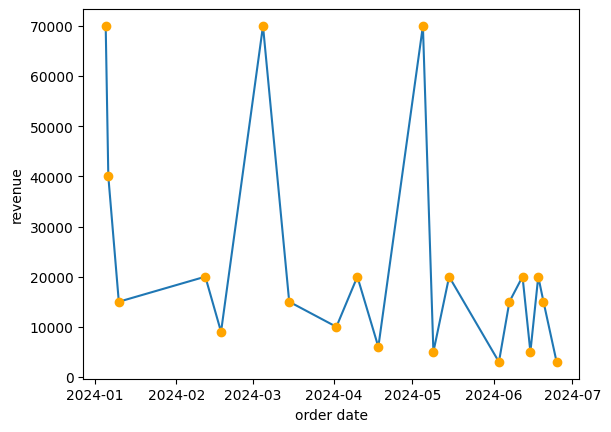

In [ ]:
# revenue trend
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("order date")
plt.ylabel("revenue")
plt.show()




The revenue is very less in the last two months (mid may,jun,jul)

In [ ]:
df["city"].unique()

array(['Hyderabad', 'Bangalore', 'Chennai'], dtype=object)

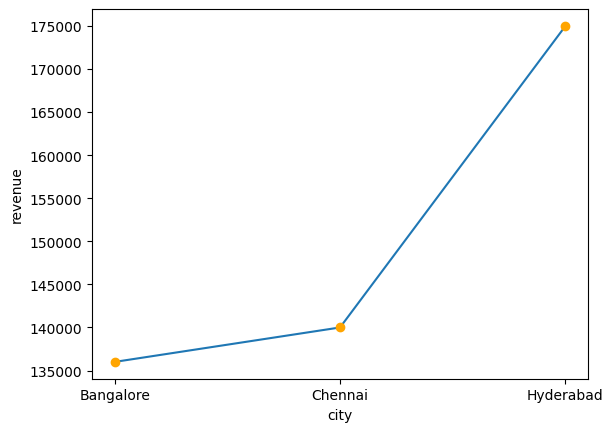

In [ ]:
# revenue trend by city
revenue_city=df.groupby("city")["revenue"].sum()
revenue_city=pd.DataFrame(revenue_city).reset_index()
plt.plot(revenue_city["city"],revenue_city["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("city")
plt.ylabel("revenue")
plt.show()

Revenue is dropping in Bangalore

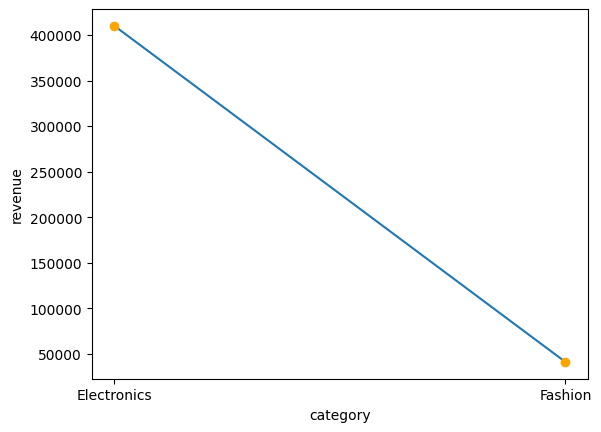

In [ ]:
# find the revenue trend by category
revenue_category=df.groupby("category")["revenue"].sum()
revenue_category=pd.DataFrame(revenue_category).reset_index()
plt.plot(revenue_category["category"],revenue_category["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("category")
plt.ylabel("revenue")
plt.show()

In fashion category revenue got dropped

In [ ]:
# count customers based on order_id(count of orders per customer)
df.groupby("customer_id")["order_id"].count()


,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


Most of the customers are ordering less

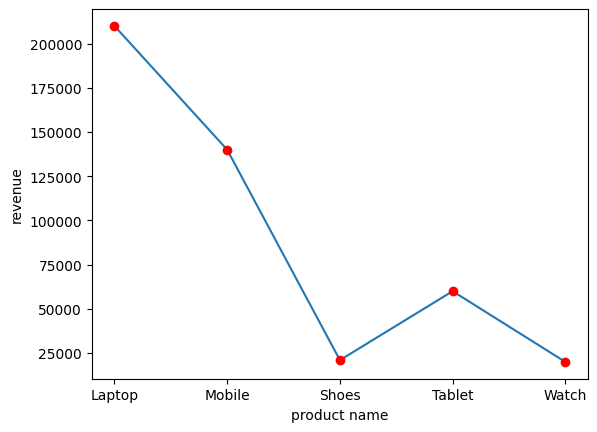

In [ ]:
# revenue trend by product name

revenue_product=df.groupby("product_name")["revenue"].sum()
revenue_product=pd.DataFrame(revenue_product).reset_index()
plt.plot(revenue_product["product_name"],revenue_product["revenue"],marker="o",mfc="red",mec="red")
plt.xlabel("product name")
plt.ylabel("revenue")
plt.show()


Revenue is very less for shoes and watch

# Insights


1.   Revenue got dropped in last two months (jun,jul)
2.   Bangalore contributed more in revenue drop
3.   Fashion category recorded less revenue
4.   Repeated customers ordered less
5.   shoe and watch sales declined significantly

# Recommendations

1.  Marketing should be done in bangalore
2.  Provide discounts for shoe and watch.
3.  coupons,discounts,loyalty programs for repeated customers.




# Hypothesis Testing

In [ ]:
# Hypothesis Testing --> an unproven fact
# def: It is a statistical method which is used to check whether a claim is true or false

# Ex: claim:
# Food delivery startup
#  claim: Average deliver time is 30 mins

# step1: Define Hypothesis
# Two key Components
#i) null hypothesis (H0)
# default claim/statement
# avg delivery time= 30 mins

# ii) alternate hypothesis(H1):
# opposite of the null hypothesis
# avg delivery time is significantly different

# step2: data collection
# collect delivery timings--> [20,25,30,45,25,15]
# we will work on this collected data

# step3: statistical testing
# T-test(most used)
# why? --> it tells how far your data is from H0

# step4: Find p-value:
# p-value --> significant value(0.05) also called alpha value
# 0.05 --> 5% (ok being wrong 5% of the time)

# if p<=0.05--> Reject null hypothesis
    # ( There is significant difference in delivery time) (avg time!=30)
# else p>0.05 --> no strong evidence to reject null hypothesis
    # (no difference) (avg time=30 minutes)


In [ ]:
# T-test : It tells us how far your data from H0

# Types
# 1) 1- Sample t-test
# 2) Independent t-test
# 3) paired t-test

In [ ]:
#1) 1- sample t-test
from scipy import stats
data=[25,30,28,32,29]
tstats,p_value=stats.ttest_1samp(data,30)
print("T stats: ",tstats)
print("P value: ",p_value)
if p_value<0.05:
  print("Reject null hypothesis")
  print("There is significantg difference between delivery timings")
else:
  print("No strong evidence to reject null hypothesis")
  print("Avg delivery time is 30 mins")



TtestResult(statistic=np.float64(-1.0366421106976316), pvalue=np.float64(0.35845634462296455), df=np.int64(4))

In [ ]:
#2) independent ttest
group1=[22,25,30,28]
group2=[35,40,38,36]

# claim: avg delivery time in both the groups are the same
tstats,p_value=stats.ttest_ind(group1,group2)
print("T stats: ",tstats)
print("P value: ",p_value)

if p_value<=0.05:
  print("Reject null hypothesis")
  print("There is significant difference between both groups")
else:
  print("No strong evidence to reject null hypothesis")
  print("Avg delivery time in both the groups are the same")


T stats:  -5.309818712280256
P value:  0.001812720788087754
Reject null hypothesis
There is significant difference between both groups


In [ ]:
#3) paired test
df= pd.read_csv("delivery_times.csv")
#claim: Did the new system reduce delivery time?
t_stats,p_value=stats.ttest_rel(df["old_time"],df["new_time"])
print("T stats: ",t_stats)
print("P value: ",p_value)
if p_value<=0.05:
  print("Reject null hypothesis")
  print("Thwere is significant difference between before and after")
else:
  print("No strong evidence to reject null hypothesis")
  print("avg difference time before and after is same")

FileNotFoundError: [Errno 2] No such file or directory: 'delivery_times.csv'